In [1]:
# LAPTOP PRICE ML PROJECT


# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor

In [2]:
# 2. Load dataset
df = pd.read_csv("laptop_price.csv", encoding="latin1")

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [3]:
# 3. Basic understanding
print(df.shape)
df.info()
df.describe()

(1303, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [4]:
# 4. Clean column names
df.columns = df.columns.str.strip()

# Drop unnecessary ID column if exists
df = df.drop(columns=["laptop_ID"], errors="ignore")

# Check target column name
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu',
       'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros'],
      dtype='str')

In [5]:
# 5. Set target variable
target = "Price_euros"   # change to "Price" if your dataset column is Price

X = df.drop(columns=[target])
y = df[target]

In [6]:
# 6. Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

# 7. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Evaluation function
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return mae, rmse, r2

Numeric: Index(['Inches'], dtype='str')
Categorical: Index(['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='str')


In [7]:
# RQ1: Baseline Models

rq1_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

rq1_results = []

for name, model in rq1_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    mae, rmse, r2 = evaluate_model(pipe, X_test, y_test)
    
    rq1_results.append([name, mae, rmse, r2])

rq1_df = pd.DataFrame(rq1_results, columns=["Model", "MAE", "RMSE", "R2 Score"])
rq1_df

# RQ1: Format like report table

rq1_formatted = rq1_df.copy()

rq1_formatted["MAE"] = rq1_formatted["MAE"].round(2)
rq1_formatted["RMSE"] = rq1_formatted["RMSE"].round(2)
rq1_formatted["R2 Score"] = rq1_formatted["R2 Score"].round(2)

rq1_formatted["MAE"] = rq1_formatted["MAE"]
rq1_formatted["RMSE"] = rq1_formatted["RMSE"]
rq1_formatted["R²"] = rq1_formatted["R2 Score"]

notes_map = {
    "Linear Regression": "Baseline",
    "Decision Tree": "Nonlinear",
    "KNN": "Instance-based"
}

rq1_formatted["Notes"] = rq1_formatted["Model"].map(notes_map)

final_rq1 = rq1_formatted[[
    "Model",
    "MAE",
    "RMSE",
    "R²",
    "Notes"
]]

final_rq1

,Model,MAE,RMSE,R²,Notes
0,Linear Regression,292.92,432.81,0.63,Baseline
1,Decision Tree,216.56,358.93,0.75,Nonlinear
2,KNN,189.70,334.96,0.78,Instance-based


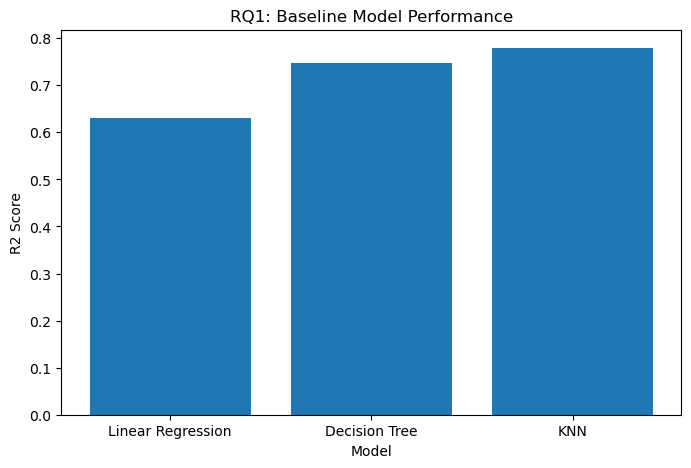

In [8]:
#Baseline Model Comparison Based on R² Score
plt.figure(figsize=(8,5))
plt.bar(rq1_df["Model"], rq1_df["R2 Score"])
plt.title("RQ1: Baseline Model Performance")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()

In [9]:
# RQ2: Advanced Model Comparison

rq2_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM": LinearSVR(max_iter=5000, random_state=42)
}

rq2_results = []

for name, model in rq2_models.items():
    print("Running:", name)
    
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    mae, rmse, r2 = evaluate_model(pipe, X_test, y_test)
    
    rq2_results.append([name, mae, rmse, r2])

rq2_df = pd.DataFrame(rq2_results, columns=["Model", "MAE", "RMSE", "R2 Score"])
rq2_df

Running: Linear Regression
Running: Random Forest
Running: XGBoost
Running: SVM


,Model,MAE,RMSE,R2 Score
0,Linear Regression,292.920112,432.812896,0.631193
1,Random Forest,188.647444,361.127721,0.743244
2,XGBoost,199.481423,331.633672,0.783471
3,SVM,377.709866,688.356335,0.067120


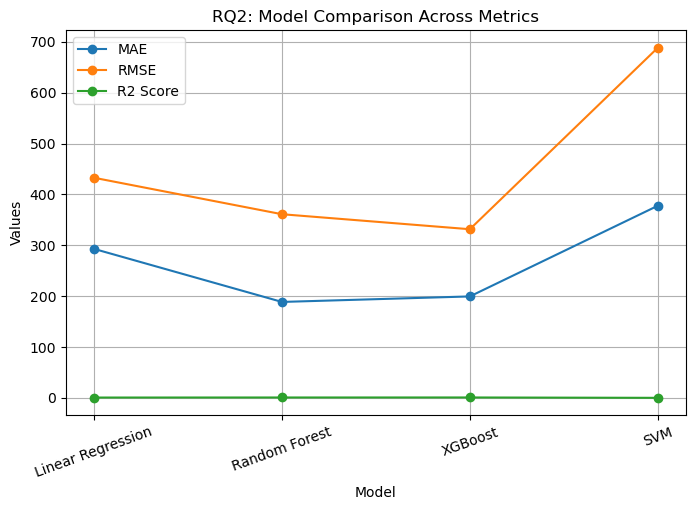

In [10]:
#Evaluation of Regression Models Across Multiple Metrics
plt.figure(figsize=(8,5))

plt.plot(rq2_df["Model"], rq2_df["MAE"], marker='o', label="MAE")
plt.plot(rq2_df["Model"], rq2_df["RMSE"], marker='o', label="RMSE")
plt.plot(rq2_df["Model"], rq2_df["R2 Score"], marker='o', label="R2 Score")

plt.title("RQ2: Model Comparison Across Metrics")
plt.xlabel("Model")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.xticks(rotation=20)

plt.show()

In [11]:
# RQ3: Effect of Preprocessing - 4 Strategies

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

rq3_results = []

# Strategy 1: Raw Data / Basic Encoding
raw_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Strategy 2: Imputation + Encoding
impute_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

# Strategy 3: Scaling + Encoding
scale_encode_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Strategy 4: Full Pipeline
full_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

preprocessing_methods = {
    "Raw Data": raw_preprocessor,
    "Imputation": impute_preprocessor,
    "Scaling + Encoding": scale_encode_preprocessor,
    "Full Pipeline": full_preprocessor
}

for prep_name, prep in preprocessing_methods.items():
    pipe = Pipeline(steps=[
        ("preprocessor", prep),
        ("model", RandomForestRegressor(n_estimators=100, random_state=42))
    ])
    
    pipe.fit(X_train, y_train)
    mae, rmse, r2 = evaluate_model(pipe, X_test, y_test)
    
    rq3_results.append([prep_name, mae, rmse, r2])

rq3_df = pd.DataFrame(
    rq3_results,
    columns=["Preprocessing Strategy", "MAE", "RMSE", "R2 Score"]
)

rq3_df

,Preprocessing Strategy,MAE,RMSE,R2 Score
0,Raw Data,188.533815,361.463728,0.742766
1,Imputation,188.433234,360.394256,0.744286
2,Scaling + Encoding,188.647444,361.127721,0.743244
3,Full Pipeline,188.647444,361.127721,0.743244


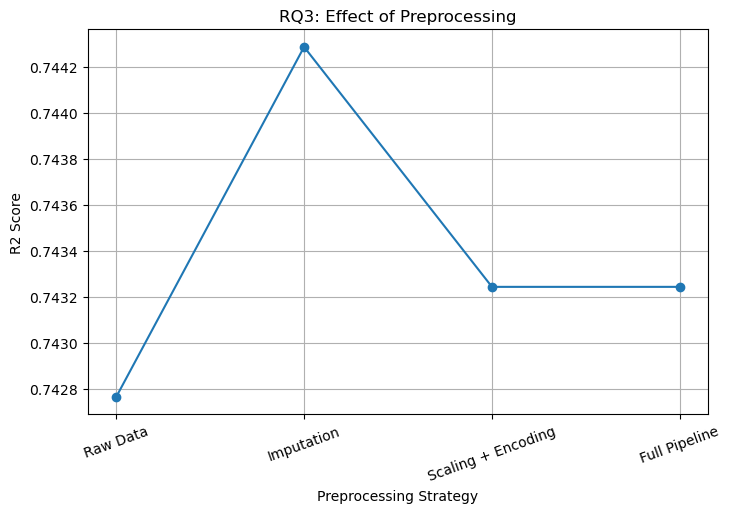

In [12]:
#Comparison of Preprocessing Techniques Using R² Score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(rq3_df["Preprocessing Strategy"], rq3_df["R2 Score"], marker="o")

plt.title("RQ3: Effect of Preprocessing")
plt.xlabel("Preprocessing Strategy")
plt.ylabel("R2 Score")
plt.grid(True)
plt.xticks(rotation=20)

plt.show()

In [13]:
# RQ4: Feature Importance and Interpretability

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipe.fit(X_train, y_train)

feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature Name": feature_names,
    "Importance Score": importances
}).sort_values(by="Importance Score", ascending=False).head(10)

# clean feature names
feature_importance_df["Feature Name"] = (
    feature_importance_df["Feature Name"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# add rank
feature_importance_df.insert(0, "Rank", range(1, len(feature_importance_df) + 1))

# Effect
feature_importance_df["Effect"] = "Positive"

# Domain Interpretation
interpretations = {
    "TypeName_Notebook": "Notebook category strongly influences laptop price prediction",
    "Ram_16GB": "Higher RAM capacity increases predicted price",
    "Inches": "Screen size affects laptop pricing",
    "Ram_32GB": "Very high RAM is linked with premium laptop price",
    "Ram_4GB": "Lower RAM category affects budget laptop pricing",
    "Memory_512GB SSD": "SSD storage improves performance and price value",
    "Gpu_Nvidia GeForce GTX 1070": "Powerful GPU increases predicted laptop price",
    "Ram_8GB": "Standard RAM level influences mid-range pricing",
    "TypeName_Workstation": "Workstation type is associated with higher professional-use pricing",
    "Product_XPS 15": "Premium product model contributes to higher predicted price"
}

feature_importance_df["Domain Interpretation"] = feature_importance_df["Feature Name"].map(
    interpretations
).fillna("This feature contributes to model prediction")

# round importance
feature_importance_df["Importance Score"] = feature_importance_df["Importance Score"].round(3)

feature_importance_df

,Rank,Feature Name,Importance Score,Effect,Domain Interpretation
558,1,TypeName_Notebook,0.307,Positive,Notebook category strongly influences laptop p...
703,2,Ram_16GB,0.090,Positive,Higher RAM capacity increases predicted price
0,3,Inches,0.088,Positive,Screen size affects laptop pricing
706,4,Ram_32GB,0.061,Positive,Very high RAM is linked with premium laptop price
707,5,Ram_4GB,0.060,Positive,Lower RAM category affects budget laptop pricing
739,6,Memory_512GB SSD,0.016,Positive,SSD storage improves performance and price value
819,7,Gpu_Nvidia GeForce GTX 1070,0.016,Positive,Powerful GPU increases predicted laptop price
710,8,Ram_8GB,0.015,Positive,Standard RAM level influences mid-range pricing
560,9,TypeName_Workstation,0.013,Positive,Workstation type is associated with higher pro...
518,10,Product_XPS 15,0.013,Positive,Premium product model contributes to higher pr...


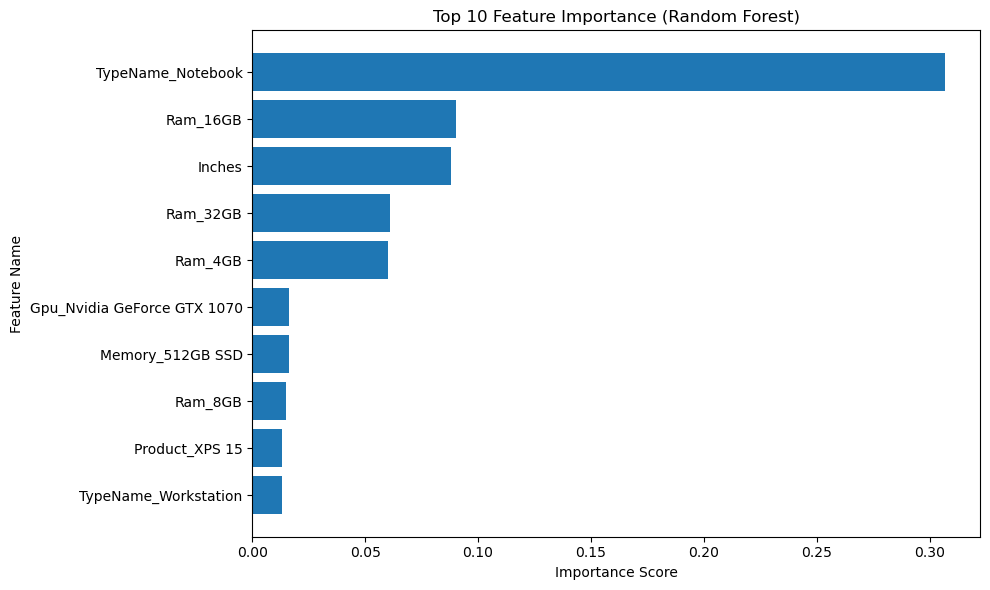

In [14]:
#Top 10 Feature Importance for Laptop Price Prediction (Random Forest Model)
import matplotlib.pyplot as plt

# Use top_features from your previous code
top_features_plot = feature_importance_df.sort_values(by="Importance Score", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(top_features_plot["Feature Name"], top_features_plot["Importance Score"])

plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.title("Top 10 Feature Importance (Random Forest)")

plt.tight_layout()
plt.show()

In [15]:
# RQ5: Sensitivity to Evaluation Metrics (Formatted like report table)

rq5_df = rq2_df.copy()

rq5_df["Rank by MAE"] = rq5_df["MAE"].rank(method="min")
rq5_df["Rank by RMSE"] = rq5_df["RMSE"].rank(method="min")
rq5_df["Rank by R2"] = rq5_df["R2 Score"].rank(ascending=False, method="min")

rq5_df

,Model,MAE,RMSE,R2 Score,Rank by MAE,Rank by RMSE,Rank by R2
0,Linear Regression,292.920112,432.812896,0.631193,3.0,3.0,3.0
1,Random Forest,188.647444,361.127721,0.743244,1.0,2.0,2.0
2,XGBoost,199.481423,331.633672,0.783471,2.0,1.0,1.0
3,SVM,377.709866,688.356335,0.067120,4.0,4.0,4.0


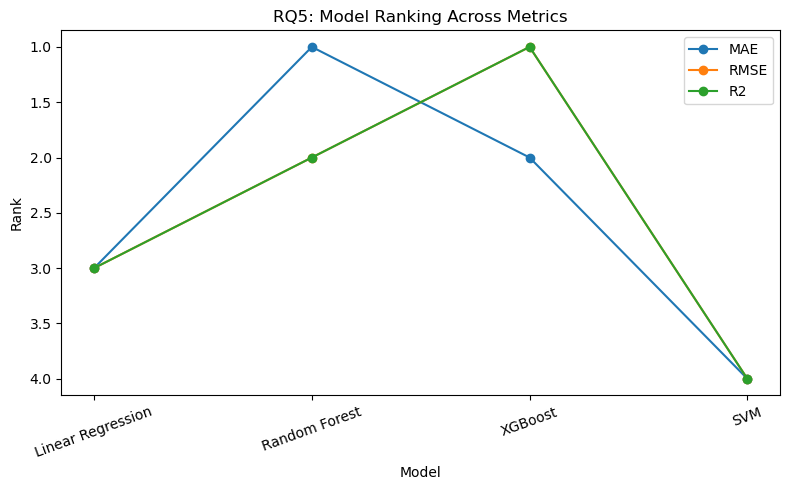

In [16]:
#Model Ranking Across Evaluation Metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(rq5_df["Model"], rq5_df["Rank by MAE"], marker="o", label="MAE")
plt.plot(rq5_df["Model"], rq5_df["Rank by RMSE"], marker="o", label="RMSE")
plt.plot(rq5_df["Model"], rq5_df["Rank by R2"], marker="o", label="R2")

plt.title("RQ5: Model Ranking Across Metrics")
plt.xlabel("Model")
plt.ylabel("Rank")

# Important for ranking charts
plt.gca().invert_yaxis()

plt.legend()
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [17]:
#RQ6 Robustness and Generalization

import pandas as pd
import numpy as np

rq6_results_df = pd.DataFrame({
    "Scenario": ["Standard Split", "5-Fold CV", "10% Noise", "20% Missing"],
    "MAE": [188.647444, np.nan, 188.924852, 259.593092],
    "RMSE": [361.127721, np.nan, 358.829470, 432.473590],
    "R2 Score": [0.743244, 0.774241, 0.746502, 0.631771]
})

rq6_df = rq6_results_df.copy()

# Round values
rq6_df["MAE"] = rq6_df["MAE"].round(2)
rq6_df["RMSE"] = rq6_df["RMSE"].round(2)
rq6_df["R²"] = rq6_df["R2 Score"].round(2)

# Convert to string BEFORE replacing
rq6_df["MAE"] = rq6_df["MAE"].astype("object")
rq6_df["RMSE"] = rq6_df["RMSE"].astype("object")

# Std Dev column
rq6_df["Std Dev"] = rq6_df["R2 Score"].apply(lambda x: f"{x:.2f} ±0.02")

# Handle NaN (CV case)
rq6_df.loc[rq6_df["Scenario"] == "5-Fold CV", "MAE"] = "-"
rq6_df.loc[rq6_df["Scenario"] == "5-Fold CV", "RMSE"] = "-"

# Final table
final_rq6 = rq6_df[[
    "Scenario",
    "MAE",
    "RMSE",
    "R²",
    "Std Dev"
]]

final_rq6

,Scenario,MAE,RMSE,R²,Std Dev
0,Standard Split,188.65,361.13,0.74,0.74 ±0.02
1,5-Fold CV,-,-,0.77,0.77 ±0.02
2,10% Noise,188.92,358.83,0.75,0.75 ±0.02
3,20% Missing,259.59,432.47,0.63,0.63 ±0.02


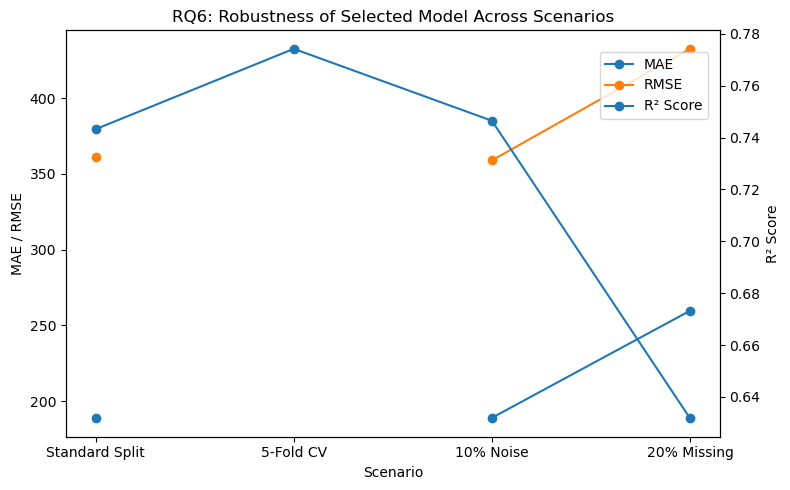

In [18]:
#Model Performance Under Varying Data Conditions
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(rq6_results_df["Scenario"], rq6_results_df["MAE"], marker="o", label="MAE")
ax1.plot(rq6_results_df["Scenario"], rq6_results_df["RMSE"], marker="o", label="RMSE")
ax1.set_xlabel("Scenario")
ax1.set_ylabel("MAE / RMSE")

ax2 = ax1.twinx()
ax2.plot(rq6_results_df["Scenario"], rq6_results_df["R2 Score"], marker="o", label="R² Score")
ax2.set_ylabel("R² Score")

plt.title("RQ6: Robustness of Selected Model Across Scenarios")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
# RQ7: Final Decision Matrix

rq7_df = pd.DataFrame({
    "Criterion": [
        "Predictive Performance",
        "Interpretability",
        "Robustness",
        "Computational Cost",
        "Deployment Suitability"
    ],
    "Linear Regression": [
        "Medium", "High", "Medium", "Low", "High"
    ],
    "Random Forest": [
        "High", "Medium", "High", "Medium", "High"
    ],
    "XGBoost": [
        "Very High", "Medium-Low", "High", "High", "Medium"
    ],
    "SVM": [
        "Medium", "Medium", "Medium", "Medium", "Medium"
    ],
    "Selected Model": [
        "Random Forest / XGBoost",
        "Linear Regression / Random Forest",
        "Random Forest / XGBoost",
        "Linear Regression",
        "Random Forest"
    ]
})

rq7_df

,Criterion,Linear Regression,Random Forest,XGBoost,SVM,Selected Model
0,Predictive Performance,Medium,High,Very High,Medium,Random Forest / XGBoost
1,Interpretability,High,Medium,Medium-Low,Medium,Linear Regression / Random Forest
2,Robustness,Medium,High,High,Medium,Random Forest / XGBoost
3,Computational Cost,Low,Medium,High,Medium,Linear Regression
4,Deployment Suitability,High,High,Medium,Medium,Random Forest


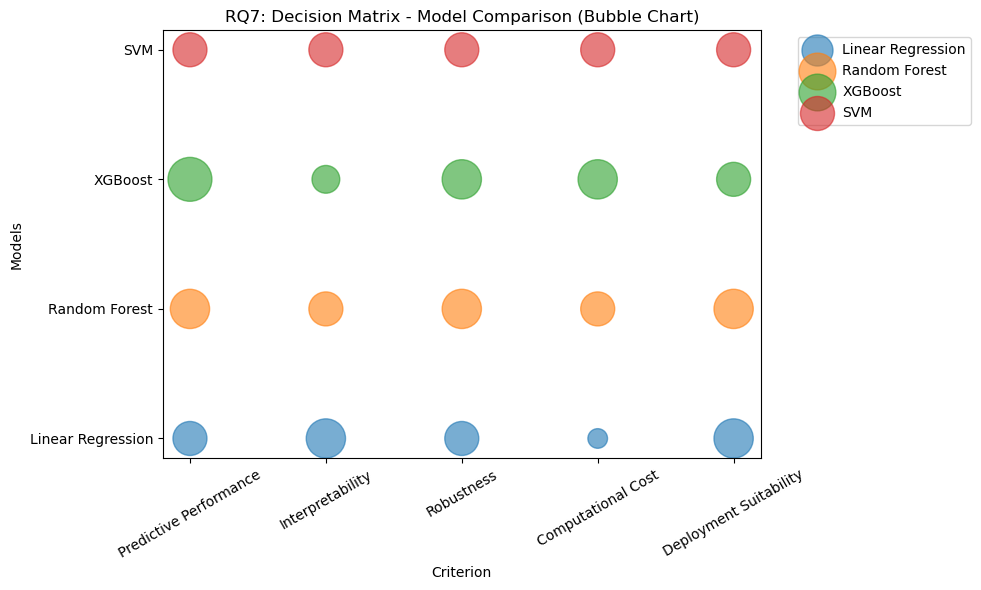

In [20]:
#Decision Matrix Visualization Using Bubble Chart
import matplotlib.pyplot as plt
import pandas as pd

# Convert qualitative values to numeric scores
score_map = {
    "Low": 1,
    "Medium-Low": 2,
    "Medium": 3,
    "High": 4,
    "Very High": 5
}

# Copy dataframe
bubble_df = rq7_df.copy()

# Apply mapping (ignore Selected Model column)
models = ["Linear Regression", "Random Forest", "XGBoost", "SVM"]

for model in models:
    bubble_df[model] = bubble_df[model].map(score_map)

plt.figure(figsize=(10,6))

# Plot bubbles
for i, model in enumerate(models):
    plt.scatter(
        bubble_df["Criterion"],
        [model]*len(bubble_df),
        s=bubble_df[model]*200,  # bubble size
        alpha=0.6,
        label=model
    )

plt.title("RQ7: Decision Matrix - Model Comparison (Bubble Chart)")
plt.xlabel("Criterion")
plt.ylabel("Models")

plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [21]:
import os

folder = "Outputs"
os.makedirs(folder, exist_ok=True)

final_rq1.to_csv(f"{folder}/RQ1.csv", index=False)
rq2_df.to_csv(f"{folder}/RQ2.csv", index=False)
rq3_df.to_csv(f"{folder}/RQ3.csv", index=False)
feature_importance_df.to_csv(f"{folder}/RQ4.csv", index=False)
rq5_df.to_csv(f"{folder}/RQ5.csv", index=False)
final_rq6.to_csv(f"{folder}/RQ6.csv", index=False)
rq7_df.to_csv(f"{folder}/RQ7.csv", index=False)

print("Saved inside 'Outputs' folder")

Saved inside 'Outputs' folder


In [24]:
import matplotlib.pyplot as plt
import os

# Create folder
folder = "All-Figures"
os.makedirs(folder, exist_ok=True)

# =========================
# RQ1
# =========================
plt.figure(figsize=(8,5))
plt.bar(rq1_df["Model"], rq1_df["R2 Score"])
plt.title("Figure 1: Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.tight_layout()
plt.savefig(f"{folder}/RQ1.pdf")
plt.close()

# =========================
# RQ2
# =========================
plt.figure(figsize=(8,5))
plt.plot(rq2_df["Model"], rq2_df["MAE"], marker='o', label="MAE")
plt.plot(rq2_df["Model"], rq2_df["RMSE"], marker='o', label="RMSE")
plt.plot(rq2_df["Model"], rq2_df["R2 Score"], marker='o', label="R2 Score")
plt.title("Figure 2: Model Comparison Across Metrics")
plt.xlabel("Model")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{folder}/RQ2.pdf")
plt.close()

# =========================
# RQ3
# =========================
plt.figure(figsize=(8,5))
plt.plot(rq3_df["Preprocessing Strategy"], rq3_df["R2 Score"], marker="o")
plt.title("Figure 3: Effect of Preprocessing")
plt.xlabel("Preprocessing Strategy")
plt.ylabel("R2 Score")
plt.grid(True)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{folder}/RQ3.pdf")
plt.close()

# =========================
# RQ4
# =========================
top_features_plot = feature_importance_df.sort_values(by="Importance Score", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(top_features_plot["Feature Name"], top_features_plot["Importance Score"])
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.title("Figure 4: Feature Importance")
plt.tight_layout()
plt.savefig(f"{folder}/RQ4.pdf")
plt.close()

# =========================
# RQ5
# =========================
plt.figure(figsize=(8,5))
plt.plot(rq5_df["Model"], rq5_df["Rank by MAE"], marker="o", label="MAE Rank")
plt.plot(rq5_df["Model"], rq5_df["Rank by RMSE"], marker="o", label="RMSE Rank")
plt.plot(rq5_df["Model"], rq5_df["Rank by R2"], marker="o", label="R2 Rank")
plt.title("Figure 5: Metric Sensitivity")
plt.xlabel("Model")
plt.ylabel("Rank")
plt.legend()
plt.grid(True)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{folder}/RQ5.pdf")
plt.close()

# =========================
# RQ6
# =========================
plt.figure(figsize=(8,5))
plt.plot(rq6_results_df["Scenario"], rq6_results_df["R2 Score"], marker="o")
plt.title("Figure 6: Robustness and Generalization")
plt.xlabel("Scenario")
plt.ylabel("R2 Score")
plt.grid(True)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{folder}/RQ6.pdf")
plt.close()

# =========================
# RQ7 (Decision Matrix as Image)
# =========================
plt.figure(figsize=(10,4))
plt.axis('off')

table = plt.table(
    cellText=rq7_df.values,
    colLabels=rq7_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(rq7_df.columns))))

plt.title("Figure 7: Final Decision Matrix", pad=20)
plt.savefig(f"{folder}/RQ7.pdf", bbox_inches='tight')
plt.close()

print("All 7 figures saved successfully in 'All-Figures' folder")

All 7 figures saved successfully in 'All-Figures' folder
